# Survey experiments

A deliberately small report focused on the question that matters here: **how often does each model pick the correct side in cross-validation?**

The headline uses a dynamic, coverage-based betting rule. For each run, the cutoff is learned from that run's CV scores and keeps at least 99% of games. The same numeric cutoff is then applied unchanged to holdout. ROI is shown as a secondary flat `-110` translation of those wins and losses—not as a tuning objective or as a claim about executable sportsbook returns.

In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import PercentFormatter

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'pyproject.toml').exists():
    raise RuntimeError('Could not find the project root containing pyproject.toml.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from training_pipeline.betting import evaluate_betting
from training_pipeline.reporting import loaders, theme
from training_pipeline.reporting.discovery import load_runs

# ---------------------------------------------------------------------------
# What to survey
SOURCES: list[str] = ['experiments/window_axis_extended_2026_08']
ARTIFACTS_ROOT = 'artifacts/experiments'
ONLY_STRATEGIES: list[str] | None = None
ONLY_COMPARISON_GROUP: str | None = None

# Keep essentially every prediction: discard only the lowest-margin 1%.
# This controls coverage only. It is not optimized against win rate or ROI.
OPERATING_COVERAGE = 0.99

# Alternative coverage levels retained in the sensitivity table.
# The final row deliberately keeps only 1% of games; nothing thinner is shown.
SENSITIVITY_COVERAGES = (0.99, 0.95, 0.90, 0.75, 0.50, 0.25, 0.10, 0.05, 0.01)
# ---------------------------------------------------------------------------

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
theme.apply_theme()

runs = theme.prepare_runs(
    load_runs(SOURCES, artifacts_root=ARTIFACTS_ROOT, project_root=PROJECT_ROOT)
)
if ONLY_STRATEGIES:
    runs = runs[runs['prediction_strategy'].isin(ONLY_STRATEGIES)]
if ONLY_COMPARISON_GROUP:
    runs = runs[runs['comparison_group'] == ONLY_COMPARISON_GROUP]
if runs.empty:
    raise ValueError('Every run was filtered out. Relax the filters above.')

# Replace terse artifact labels with the question each model answers.
# Any suffix added by theme.prepare_runs (for example, a changed data or
# cleaning setting) is retained so genuinely different runs stay distinct.
STRATEGY_DESCRIPTIONS = {
    'line_error_regressor': 'Predicts error vs bookmaker line',
    'total_points_regressor': 'Predicts final total points',
    'over_under_classifier': 'Predicts over/under probability',
}


def descriptive_run_label(run: pd.Series) -> str:
    window_raw = str(int(run['train_games'])) if pd.notna(run['train_games']) else '<NA>'
    old_prefix = f"{run['strategy_short']} · {window_raw}"
    old_label = str(run['label'])
    suffix = old_label[len(old_prefix):] if old_label.startswith(old_prefix) else ''
    description = STRATEGY_DESCRIPTIONS.get(
        run['prediction_strategy'], str(run['prediction_strategy']).replace('_', ' ')
    )
    window = f"{int(run['train_games']):,}-game window" if pd.notna(run['train_games']) else 'full-history window'
    return f'{description} · {window}{suffix}'


runs['label'] = runs.apply(descriptive_run_label, axis=1)

print(f"{len(runs)} run(s) loaded from {runs['source_path'].nunique()} folder(s).")
display(runs[['label', 'prediction_strategy', 'train_games', 'created_at']])

3 run(s) loaded from 1 folder(s).


,label,prediction_strategy,train_games,created_at
0,"Predicts error vs bookmaker line · 3,000-game window",line_error_regressor,3000,2026-08-20 12:10:30.434830+00:00
1,"Predicts error vs bookmaker line · 4,500-game window",line_error_regressor,4500,2026-08-20 14:28:44.396293+00:00
2,"Predicts error vs bookmaker line · 6,500-game window",line_error_regressor,6500,2026-08-20 16:56:28.722488+00:00


## Dynamic threshold

A fixed `0.5`-point rule answers a different question for every model because their score distributions differ. Here the rule is expressed as **coverage** instead:

1. Find the score cutoff that keeps at least 99% of that run's CV games.
2. Score CV at that cutoff.
3. Freeze the cutoff and apply it to holdout.

The cutoff is therefore not chosen for a favorable win rate, and holdout never influences it. Tied scores can make realized coverage slightly higher than the target. Regressor thresholds are in points; classifier thresholds are in expected-value units.

In [12]:
def threshold_for_coverage(frame: pd.DataFrame, coverage: float) -> float:
    """CV score cutoff that retains at least ``coverage`` of candidates."""
    if not 0 < coverage <= 1:
        raise ValueError('coverage must be in (0, 1].')
    scores = (
        pd.to_numeric(frame['selection_score'], errors='coerce')
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    if scores.empty:
        return float('nan')

    # evaluate_betting selects score > threshold. Moving one float below
    # the empirical cutoff includes the boundary and makes coverage robust
    # to discrete/tied scores.
    cutoff = float(scores.quantile(1.0 - coverage, interpolation='higher'))
    return float(np.nextafter(cutoff, -np.inf))


def score_predictions(
    run: pd.Series, source: str, frame: pd.DataFrame, threshold: float
) -> dict[str, object]:
    metrics = evaluate_betting(
        predicted_edge=frame['predicted_edge'],
        actual_total=frame['TOTAL_POINTS'],
        line=frame['target_line'],
        selection_score=frame['selection_score'],
        min_edge=threshold,
        # Deliberately flat -110: prediction artifacts do not consistently
        # retain executable per-bet prices.
        flat_decimal_odds=theme.DECIMAL_ODDS,
    ).model_dump()
    return {
        'label': run['label'],
        'prediction_strategy': run['prediction_strategy'],
        'source': source,
        'threshold': threshold,
        'threshold_units': 'EV' if run['is_classifier'] else 'points',
        **metrics,
    }


prediction_cache: dict[str, dict[str, pd.DataFrame]] = {}
operating_rows: list[dict[str, object]] = []
missing_cv: list[str] = []

for _, run in runs.iterrows():
    predictions = dict(loaders.load_all_predictions(run, drop_pushes=False))
    prediction_cache[run['label']] = predictions
    cv = predictions.get('cross-validation')
    if cv is None or cv.empty:
        missing_cv.append(run['label'])
        continue

    threshold = threshold_for_coverage(cv, OPERATING_COVERAGE)
    for source, frame in predictions.items():
        operating_rows.append(score_predictions(run, source, frame, threshold))

operating = pd.DataFrame(operating_rows)
if operating.empty:
    raise ValueError('No usable CV prediction artifacts were found for these runs.')
if missing_cv:
    print(f'No usable CV predictions for: {missing_cv}')

threshold_summary = (
    operating.pivot_table(
        index=['label', 'threshold', 'threshold_units'],
        columns='source',
        values='bet_rate',
        observed=True,
    )
    .reset_index()
    .rename(columns={
        'cross-validation': 'cv_games_kept',
        'holdout': 'holdout_games_kept',
    })
)
display(
    threshold_summary.style.format(
        {
            'threshold': '{:.4f}',
            'cv_games_kept': '{:.1%}',
            'holdout_games_kept': '{:.1%}',
        },
        na_rep='—',
    )
)

source,label,threshold,threshold_units,cv_games_kept,holdout_games_kept
0,"Predicts error vs bookmaker line · 3,000-game window",0.0111,points,98.9%,99.8%
1,"Predicts error vs bookmaker line · 4,500-game window",0.0162,points,98.9%,99.3%
2,"Predicts error vs bookmaker line · 6,500-game window",0.0170,points,98.9%,99.8%


## Headline: CV versus holdout win rate, plus flat-odds ROI

CV and holdout win rates are plotted together so any out-of-sample drop is visible directly. The error bars are **95% Wilson confidence intervals** around each observed win rate. They represent sampling uncertainty from the finite number of decided bets—not variation across seeds, folds, or individual prediction errors. Pushes are excluded, and holdout intervals are usually wider because holdout has fewer games. ROI is the CV result translated to one-unit bets at a flat `-110`; it contains no extra model information and is retained only as an intuitive diagnostic.

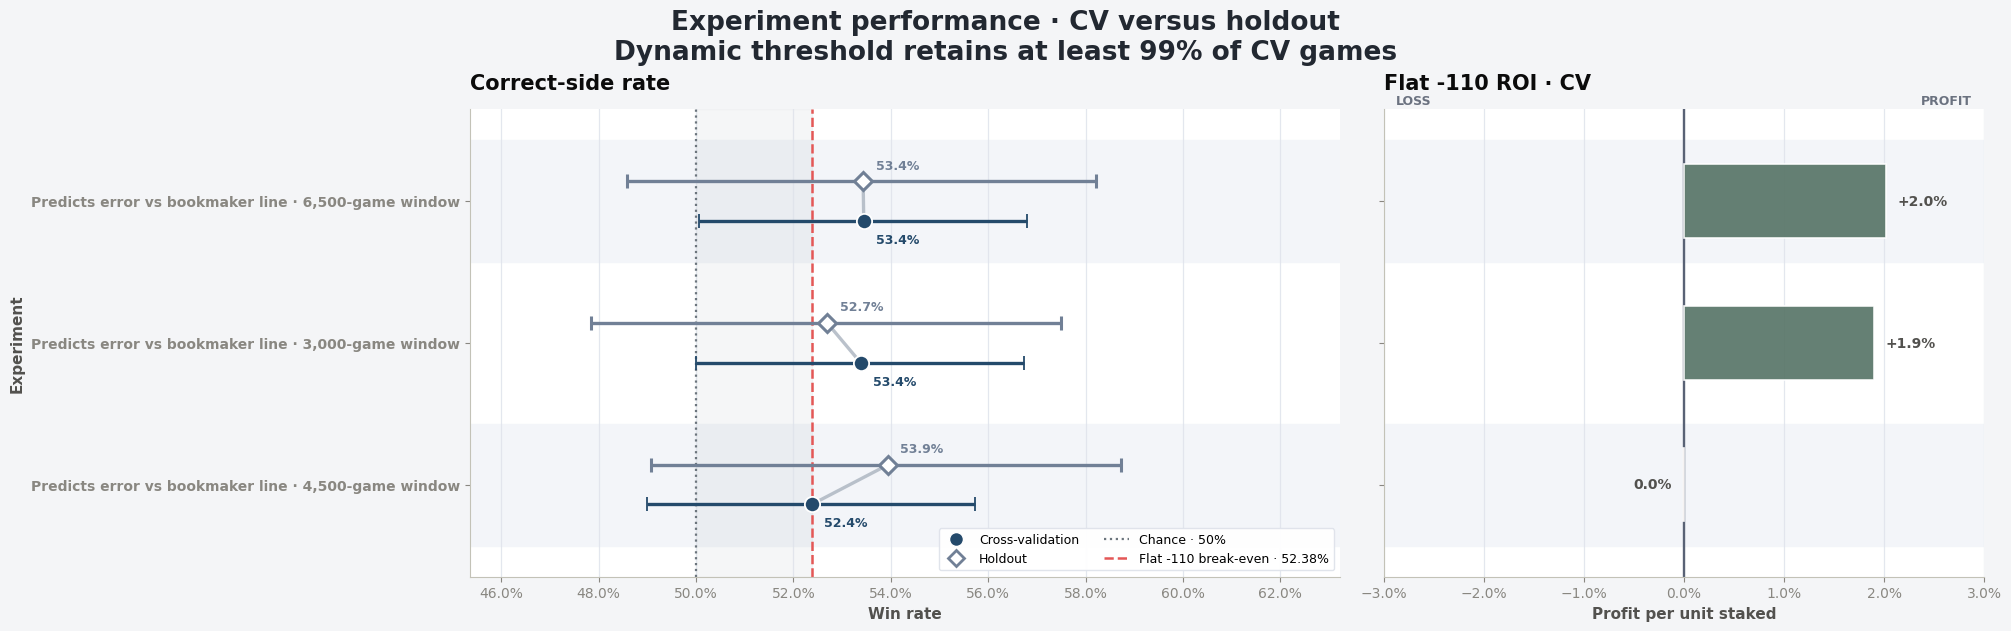

,label,threshold,threshold_units,cv_candidates,cv_bets,cv_games_kept,cv_win_rate,cv_ci_low,cv_ci_high,cv_flat_minus_110_roi,holdout_candidates,holdout_bets,holdout_games_kept,holdout_win_rate,holdout_ci_low,holdout_ci_high
0,"Predicts error vs bookmaker line · 4,500-game window",0.0162,points,855,846,98.9%,52.38%,49.00%,55.73%,-0.01%,416,413,99.3%,53.94%,49.08%,58.73%
1,"Predicts error vs bookmaker line · 3,000-game window",0.0111,points,855,846,98.9%,53.38%,50.01%,56.73%,1.90%,416,415,99.8%,52.70%,47.85%,57.49%
2,"Predicts error vs bookmaker line · 6,500-game window",0.0170,points,855,846,98.9%,53.44%,50.07%,56.79%,2.02%,416,415,99.8%,53.43%,48.58%,58.22%


In [13]:
cv = (
    operating[operating['source'] == 'cross-validation']
    .sort_values(['win_rate', 'label'])
    .reset_index(drop=True)
)
holdout = (
    operating[operating['source'] == 'holdout']
    .drop_duplicates('label', keep='last')
    .set_index('label')
)
positions = np.arange(len(cv))
# Restrained report palette: source is encoded consistently across runs,
# while marker shape remains a redundant CV/holdout cue.
CV_COLOR = '#244a6b'
HOLDOUT_COLOR = '#718096'
CONNECTOR_COLOR = '#aeb7c2'
ROI_POSITIVE = '#587568'
ROI_NEGATIVE = '#8a6060'
colours = [CV_COLOR] * len(cv)
height = max(6.2, 0.95 * len(cv) + 3.0)
fig, axes = plt.subplots(
    1, 2, figsize=(20, height), sharey=True,
    gridspec_kw={'width_ratios': [1.45, 1.0]},
    constrained_layout=True,
)
fig.patch.set_facecolor('#f4f5f7')

for ax in axes:
    ax.set_facecolor('#ffffff')
    ax.grid(axis='x', color='#dfe3eb', linewidth=0.9, alpha=0.85)
    ax.grid(axis='y', visible=False)
    ax.tick_params(labelsize=10)
    for position in positions:
        if position % 2 == 0:
            ax.axhspan(position - 0.43, position + 0.43, color='#f3f5f9', zorder=0)

# A very light neutral band separates chance from flat -110 break-even.
axes[0].axvspan(0.50, theme.BREAK_EVEN, color='#7a8490', alpha=0.07, zorder=0)
win_bounds = [0.50, theme.BREAK_EVEN]

# Paired dumbbells: the connector makes the CV-to-holdout movement visible.
for position, (_, row), colour in zip(positions, cv.iterrows(), colours, strict=True):
    has_holdout = row['label'] in holdout.index
    cv_position = position - 0.14 if has_holdout else position
    cv_low = row['win_rate'] - row['win_rate_ci_low']
    cv_high = row['win_rate_ci_high'] - row['win_rate']
    win_bounds.extend([row['win_rate_ci_low'], row['win_rate_ci_high']])

    if has_holdout and pd.notna(holdout.loc[row['label'], 'win_rate']):
        test = holdout.loc[row['label']]
        test_position = position + 0.14
        axes[0].plot(
            [row['win_rate'], test['win_rate']], [cv_position, test_position],
            color=CONNECTOR_COLOR, linewidth=2.4, alpha=0.85, zorder=1,
        )
        test_low = test['win_rate'] - test['win_rate_ci_low']
        test_high = test['win_rate_ci_high'] - test['win_rate']
        win_bounds.extend([test['win_rate_ci_low'], test['win_rate_ci_high']])
        axes[0].errorbar(
            test['win_rate'], test_position,
            xerr=np.array([[test_low], [test_high]]),
            fmt='D', color=HOLDOUT_COLOR, markerfacecolor='white',
            markeredgewidth=2.2, elinewidth=2.4, capsize=5,
            capthick=2.0, markersize=9, zorder=4,
        )
        axes[0].annotate(
            f"{test['win_rate']:.1%}", (test['win_rate'], test_position),
            xytext=(9, 9), textcoords='offset points', fontsize=9,
            fontweight='semibold', color=HOLDOUT_COLOR,
        )

    axes[0].errorbar(
        row['win_rate'], cv_position, xerr=np.array([[cv_low], [cv_high]]),
        fmt='o', color=colour, markeredgecolor='white', markeredgewidth=1.3,
        elinewidth=2.4, capsize=5, capthick=2.0, markersize=11, zorder=5,
    )
    axes[0].annotate(
        f"{row['win_rate']:.1%}", (row['win_rate'], cv_position),
        xytext=(9, -16 if has_holdout else 9), textcoords='offset points',
        fontsize=9, fontweight='semibold', color=colour,
    )

axes[0].plot(
    [], [], 'o', color=CV_COLOR, markeredgecolor='white', markersize=10,
    linestyle='', label='Cross-validation',
)
axes[0].plot(
    [], [], marker='D', markerfacecolor='white', markeredgecolor=HOLDOUT_COLOR,
    markeredgewidth=2, markersize=8, linestyle='', label='Holdout',
)
axes[0].axvline(
    0.50, color='#6c757d', linewidth=1.6, linestyle=':', label='Chance · 50%',
)
axes[0].axvline(
    theme.BREAK_EVEN, color='#e45756', linewidth=1.8, linestyle='--',
    label='Flat -110 break-even · 52.38%',
)
win_left = max(0.0, float(np.nanmin(win_bounds)) - 0.025)
win_right = min(1.0, float(np.nanmax(win_bounds)) + 0.045)
axes[0].set_xlim(win_left, win_right)
axes[0].set_title('Correct-side rate', loc='left', fontsize=15, fontweight='bold', pad=14)
axes[0].set_xlabel('Win rate', fontsize=11, fontweight='semibold')
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend(
    loc='lower right', ncol=2, fontsize=9, frameon=True,
    facecolor='white', edgecolor='#dfe3eb', framealpha=0.96,
)

# ROI remains secondary. Muted sign colours communicate direction without
# turning the diagnostic panel into the visual focus.
roi_values = pd.to_numeric(cv['roi'], errors='coerce')
finite_roi = roi_values[np.isfinite(roi_values)]
roi_limit = max(0.03, float(finite_roi.abs().max()) * 1.45) if not finite_roi.empty else 0.10
axes[1].set_xlim(-roi_limit, roi_limit)
roi_colours = [
    ROI_POSITIVE if value > 0 else ROI_NEGATIVE if value < 0 else '#7a8490'
    for value in roi_values
]
bars = axes[1].barh(
    positions, roi_values, color=roi_colours, height=0.52, alpha=0.92,
    edgecolor='white', linewidth=1.2, zorder=3,
)
axes[1].axvline(0.0, color='#596275', linewidth=1.7, zorder=2)
axes[1].set_title('Flat -110 ROI · CV', loc='left', fontsize=15, fontweight='bold', pad=14)
axes[1].set_xlabel('Profit per unit staked', fontsize=11, fontweight='semibold')
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].text(0.02, 1.01, 'LOSS', transform=axes[1].transAxes, color='#6b7280', fontsize=9, fontweight='bold')
axes[1].text(
    0.98, 1.01, 'PROFIT', transform=axes[1].transAxes, color='#6b7280',
    fontsize=9, fontweight='bold', ha='right',
)
for bar, value in zip(bars, roi_values, strict=True):
    if pd.isna(value):
        continue
    roi_label = '0.0%' if np.isclose(value, 0.0, atol=0.0005) else f'{value:+.1%}'
    offset = 8 if value >= 0 else -8
    axes[1].annotate(
        roi_label, (value, bar.get_y() + bar.get_height() / 2),
        xytext=(offset, 0), textcoords='offset points', va='center',
        ha='left' if value >= 0 else 'right', fontsize=10,
        fontweight='bold', color=theme.INK_2,
    )

axes[0].set_yticks(positions, cv['label'], fontsize=10, fontweight='semibold')
axes[0].set_ylabel('Experiment', fontsize=11, fontweight='semibold')
axes[0].set_ylim(-0.65, len(cv) - 0.35)
fig.suptitle(
    'Experiment performance · CV versus holdout\n'
    f'Dynamic threshold retains at least {OPERATING_COVERAGE:.0%} of CV games',
    fontsize=19, fontweight='bold', color='#222831',
)
plt.show()

headline = cv[[
    'label', 'threshold', 'threshold_units', 'n_candidates', 'n_bets',
    'bet_rate', 'win_rate', 'win_rate_ci_low', 'win_rate_ci_high', 'roi',
]].rename(columns={
    'n_candidates': 'cv_candidates',
    'n_bets': 'cv_bets',
    'bet_rate': 'cv_games_kept',
    'win_rate': 'cv_win_rate',
    'win_rate_ci_low': 'cv_ci_low',
    'win_rate_ci_high': 'cv_ci_high',
    'roi': 'cv_flat_minus_110_roi',
})
holdout_headline = (
    operating[operating['source'] == 'holdout'][[
        'label', 'n_candidates', 'n_bets', 'bet_rate', 'win_rate',
        'win_rate_ci_low', 'win_rate_ci_high',
    ]]
    .rename(columns={
        'n_candidates': 'holdout_candidates',
        'n_bets': 'holdout_bets',
        'bet_rate': 'holdout_games_kept',
        'win_rate': 'holdout_win_rate',
        'win_rate_ci_low': 'holdout_ci_low',
        'win_rate_ci_high': 'holdout_ci_high',
    })
)
headline = headline.merge(holdout_headline, on='label', how='left')
display(headline.style.format({
    'threshold': '{:.4f}',
    'cv_games_kept': '{:.1%}',
    'cv_win_rate': '{:.2%}',
    'cv_ci_low': '{:.2%}',
    'cv_ci_high': '{:.2%}',
    'cv_flat_minus_110_roi': '{:.2%}',
    'holdout_games_kept': '{:.1%}',
    'holdout_win_rate': '{:.2%}',
    'holdout_ci_low': '{:.2%}',
    'holdout_ci_high': '{:.2%}',
}, na_rep='—'))

## Threshold sensitivity

This keeps the useful threshold table without pretending that one cutoff was known in advance. Each row starts from a target share of CV games, derives the corresponding CV cutoff, and applies that same cutoff to holdout. The table stops at 1% coverage because anything thinner is too easy to make look good by chance.

Read `CV games` beside `CV win`; a higher win rate on very few games is not automatically a better model. `Holdout win` is a forward check, not another criterion for choosing the threshold.

In [14]:
sensitivity_rows: list[dict[str, object]] = []
for _, run in runs.iterrows():
    predictions = prediction_cache.get(run['label'], {})
    cv_frame = predictions.get('cross-validation')
    if cv_frame is None or cv_frame.empty:
        continue

    for target_coverage in SENSITIVITY_COVERAGES:
        threshold = threshold_for_coverage(cv_frame, target_coverage)
        for source, frame in predictions.items():
            row = score_predictions(run, source, frame, threshold)
            row['target_coverage'] = target_coverage
            sensitivity_rows.append(row)

sensitivity = pd.DataFrame(sensitivity_rows)
cv_sensitivity = (
    sensitivity[sensitivity['source'] == 'cross-validation'][[
        'label', 'target_coverage', 'threshold', 'threshold_units',
        'bet_rate', 'n_bets', 'win_rate', 'roi',
    ]]
    .rename(columns={
        'bet_rate': 'cv_games',
        'n_bets': 'cv_bets',
        'win_rate': 'cv_win',
        'roi': 'cv_flat_roi',
    })
)
holdout_sensitivity = (
    sensitivity[sensitivity['source'] == 'holdout'][[
        'label', 'target_coverage', 'threshold', 'bet_rate', 'n_bets',
        'win_rate', 'roi',
    ]]
    .rename(columns={
        'bet_rate': 'holdout_games',
        'n_bets': 'holdout_bets',
        'win_rate': 'holdout_win',
        'roi': 'holdout_flat_roi',
    })
)
threshold_table = (
    cv_sensitivity.merge(
        holdout_sensitivity,
        on=['label', 'target_coverage', 'threshold'],
        how='left',
    )
    .sort_values(['label', 'target_coverage'], ascending=[True, False])
    .reset_index(drop=True)
)

display(threshold_table.style.format({
    'target_coverage': '{:.0%}',
    'threshold': '{:.4f}',
    'cv_games': '{:.1%}',
    'cv_win': '{:.2%}',
    'cv_flat_roi': '{:.2%}',
    'holdout_games': '{:.1%}',
    'holdout_win': '{:.2%}',
    'holdout_flat_roi': '{:.2%}',
}, na_rep='—'))

,label,target_coverage,threshold,threshold_units,cv_games,cv_bets,cv_win,cv_flat_roi,holdout_games,holdout_bets,holdout_win,holdout_flat_roi
0,"Predicts error vs bookmaker line · 3,000-game window",99%,0.0111,points,98.9%,846,53.38%,1.90%,99.8%,415,52.70%,0.59%
1,"Predicts error vs bookmaker line · 3,000-game window",95%,0.0537,points,95.0%,812,53.77%,2.64%,97.8%,407,52.87%,0.92%
2,"Predicts error vs bookmaker line · 3,000-game window",90%,0.1093,points,89.9%,769,53.66%,2.42%,93.3%,388,52.88%,0.94%
3,"Predicts error vs bookmaker line · 3,000-game window",75%,0.2945,points,75.0%,641,53.36%,1.87%,76.7%,319,52.70%,0.60%
4,"Predicts error vs bookmaker line · 3,000-game window",50%,0.6340,points,50.1%,428,51.88%,-0.96%,48.3%,201,50.51%,-3.53%
5,"Predicts error vs bookmaker line · 3,000-game window",25%,1.0825,points,25.0%,214,56.54%,7.94%,25.7%,107,52.38%,-0.00%
6,"Predicts error vs bookmaker line · 3,000-game window",10%,1.6091,points,10.1%,86,61.63%,17.65%,11.3%,47,55.32%,5.61%
7,"Predicts error vs bookmaker line · 3,000-game window",5%,1.9866,points,5.0%,43,62.79%,19.87%,6.0%,25,52.00%,-0.73%
8,"Predicts error vs bookmaker line · 3,000-game window",1%,2.6824,points,1.1%,9,55.56%,6.06%,2.6%,11,45.45%,-13.22%
9,"Predicts error vs bookmaker line · 4,500-game window",99%,0.0162,points,98.9%,846,52.38%,-0.01%,99.3%,413,53.94%,2.93%


## Configuration sanity check

Only result-affecting fields that vary across the selected runs are shown. This is a compact guard against attributing a difference to the model when another setting changed at the same time.

In [15]:
LABEL_KEYS = {
    'experiment_name', 'training_version', 'comparison_group', 'hypothesis', 'tags',
    'data.data_version', 'data.expected_checksum', 'window_dir_label',
    'window_name_label', 'experiment_root_dir', 'model_output_root',
    'save_experiment_artifacts',
}
configs = {row['label']: loaders.load_config_flat(row) for _, row in runs.iterrows()}
configs = {label: config for label, config in configs.items() if config}
if not configs:
    display(Markdown('_No `config.json` files found._'))
else:
    matrix = pd.DataFrame(configs).sort_index()
    varies = matrix.apply(lambda row: row.astype(str).nunique(dropna=False) > 1, axis=1)
    substantive = matrix.loc[varies & ~matrix.index.isin(LABEL_KEYS)]
    display(
        substantive
        if not substantive.empty
        else Markdown('_No result-affecting configuration differences._')
    )

,"Predicts error vs bookmaker line · 3,000-game window","Predicts error vs bookmaker line · 4,500-game window","Predicts error vs bookmaker line · 6,500-game window"
walk_forward.train_games,3000,4500,6500
